# Dr. Case Notebook
# Applied Analytics (EDA)

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Denise Case](https://github.com/denisecase/)
- Repository: [datafun-06-applied](https://github.com/denisecase/datafun-06-applied/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06

## Instructions

- Scan the headings first, to get an idea of the process and overall goal. 
- The provided content is a well-structured example that shows the process.
- Seek to understand the process and presentation of the work. 
- The goal is to be able to perform EDA **on any data you choose**. 
- Clean up your copy of this notebook as you work - remove lines indicating the cell type, etc.

## Dataset Information

- Dataset: Our World in Data CO2 / energy dataset
- A subset with United States, China, India, Germany, United Kingdom,
  France, Japan, Brazil, Canada, World for years 1990-present
  has been **used for the example**.
- GitHub: <https://github.com/owid/co2-data>
- Explorer: <https://ourworldindata.org/explorers/co2>
  
This is a Markdown cell.

## Section 0a. Intro to Jupyter Notebooks

This is a Markdown cell (not a Python cell). 
Here are a few tips to help you get started with Jupyter Notebooks:

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when you're done editing the cell.
- You can change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- You can rearrange cells by dragging and dropping them within the notebook.
- After creating a new notebook, use **File > Save as** to rename and save it into your project repository `notebooks` folder.
- To select a kernel (Python environment) for your notebook in Visual Studio Code, click on the **Select Kernel** name in the top-right corner of the notebook interface and choose the desired kernel from the dropdown menu. 
- Follow suggestions to install recommended extensions. 
- Once installed, click Select Kernel / Python Environments and choose the Recommended `.venv` option created earlier. 
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

Once skilled with Notebooks, you can delete this entire cell or create custom notes.

This is a Markdown cell.  


## Section 0b. Intro to EDA

### WHEN to do EDA

Perform Exploratory Data Analysis (EDA) when encountering a new data source, even if:

- You did not collect the data
- Someone else already analyzed it
- It comes from a trusted system

EDA helps to understand:

- What data is actually available
- What is missing, duplicated, or inconsistent
- What questions the data can and cannot answer

### GOALS of EDA

EDA is not the final report. EDA is about:

- Understanding structure and scale
- Detecting issues early
- Identifying next steps (cleaning, modeling, collection)

This notebook shows a standard EDA workflow that works for most **tabular** datasets.

Once you understand EDA, you can delete this entire cell or create custom notes.

This is a Markdown cell.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

This is a Markdown cell.

In [201]:
# This is a Python cell.

# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("P06-NB", level="DEBUG")
log_header(LOG, "P06-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "airline-safety"

# CUSTOM: Grouping column
GROUP_COL: Final[str] = "airline"

# Load dataset
df: pd.DataFrame = pd.read_csv("../data/raw/airline-safety.csv")

# CUSTOM: Numeric columns to analyze
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "avail_seat_km_per_week",
    "incidents_85_99",
    "fatal_accidents_85_99",
    "incidents_00_14",
    "fatalities_00_14",
]

# CUSTOM: Example numeric column
EXAMPLE_NUMERIC_COL: Final[str] = "incidents_00_14"

# CUSTOM: Scatter plot variables
SCATTER_X_COL: Final[str] = "avail_seat_km_per_week"
SCATTER_Y_COL: Final[str] = "incidents_00_14"

BOX_Y_COL: Final[str] = "fatalities_00_14"

# CUSTOM: Labels
SCATTER_X_LABEL: Final[str] = "Available seat km per week"
SCATTER_Y_LABEL: Final[str] = "Incidents (2000–2014)"

BOX_Y_LABEL: Final[str] = "Fatalities (2000–2014)"

# === Section 1d. Pandas Configuration ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-09 13:45:28 | INFO | P06-NB | === RUN START ===
2026-06-09 13:45:28 | INFO | P06-NB | project=P06-NB
2026-06-09 13:45:28 | INFO | P06-NB | repo_dir=datafun-06-applied
2026-06-09 13:45:28 | INFO | P06-NB | python=3.14.5
2026-06-09 13:45:28 | INFO | P06-NB | os=Windows 11
2026-06-09 13:45:28 | INFO | P06-NB | shell=powershell
2026-06-09 13:45:28 | INFO | P06-NB | cwd=notebooks
2026-06-09 13:45:28 | INFO | P06-NB | github_actions=False
2026-06-09 13:45:28 | INFO | P06-NB | Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

This is a Markdown cell.

In [202]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the dataset into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")

df: pd.DataFrame = pd.read_csv("../data/raw/airline-safety.csv")

count_of_rows: int = df.shape[0]
count_of_columns: int = df.shape[1]

LOG.info(f"Loaded: {count_of_rows} rows, {count_of_columns} columns")

2026-06-09 13:45:28 | INFO | P06-NB | Loading dataset: airline-safety
2026-06-09 13:45:28 | INFO | P06-NB | Loaded: 56 rows, 8 columns


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

This is a Markdown cell.

In [203]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-09 13:45:28 | INFO | P06-NB | Previewing first few rows of the dataset


,airline,avail_seat_km_per_week,incidents_85_99,fatal_accidents_85_99,fatalities_85_99,incidents_00_14,fatal_accidents_00_14,fatalities_00_14
0,Aer Lingus,320906734,2,0,0,0,0,0
1,Aeroflot*,1197672318,76,14,128,6,1,88
2,Aerolineas Argentinas,385803648,6,0,0,1,0,0
3,Aeromexico*,596871813,3,1,64,5,0,0
4,Air Canada,1865253802,2,0,0,2,0,0


In [204]:
# Section 3 Python cell

LOG.info("Column names")
column_names: list[str] = list(df.columns)
print(column_names)

2026-06-09 13:45:28 | INFO | P06-NB | Column names


['airline', 'avail_seat_km_per_week', 'incidents_85_99', 'fatal_accidents_85_99', 'fatalities_85_99', 'incidents_00_14', 'fatal_accidents_00_14', 'fatalities_00_14']


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

This is a Markdown cell.


In [205]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-09 13:45:28 | INFO | P06-NB | Building starter data dictionary
2026-06-09 13:45:28 | DEBUG | P06-NB | 
                   column  dtype  missing_count  missing_pct
0                 airline    str              0          0.0
1  avail_seat_km_per_week  int64              0          0.0
2         incidents_85_99  int64              0          0.0
3   fatal_accidents_85_99  int64              0          0.0
4        fatalities_85_99  int64              0          0.0
5         incidents_00_14  int64              0          0.0
6   fatal_accidents_00_14  int64              0          0.0
7        fatalities_00_14  int64              0          0.0


In [206]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-09 13:45:28 | INFO | P06-NB | Missing values per column:
2026-06-09 13:45:28 | INFO | P06-NB | airline                   0
avail_seat_km_per_week    0
incidents_85_99           0
fatal_accidents_85_99     0
fatalities_85_99          0
incidents_00_14           0
fatal_accidents_00_14     0
fatalities_00_14          0
dtype: int64
2026-06-09 13:45:28 | INFO | P06-NB | Checking missing values per column
2026-06-09 13:45:28 | DEBUG | P06-NB | 
airline                   0
avail_seat_km_per_week    0
incidents_85_99           0
fatal_accidents_85_99     0
fatalities_85_99          0
incidents_00_14           0
fatal_accidents_00_14     0
fatalities_00_14          0
dtype: int64
2026-06-09 13:45:28 | INFO | P06-NB | Duplicate rows detected: 0
2026-06-09 13:45:28 | INFO | P06-NB | Call describe() for numeric columns
2026-06-09 13:45:28 | DEBUG | P06-NB | 
       avail_seat_km_per_week  incidents_85_99  fatal_accidents_85_99  incidents_00_14  fatalities_00_14
count            5.600000e

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

This is a Markdown cell.

In [207]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-09 13:45:28 | DEBUG | P06-NB | Columns required to be non-missing: ['avail_seat_km_per_week', 'incidents_85_99', 'fatal_accidents_85_99', 'incidents_00_14', 'fatalities_00_14', 'airline']
2026-06-09 13:45:28 | INFO | P06-NB | Original rows: 56
2026-06-09 13:45:28 | INFO | P06-NB | Clean rows:    56
2026-06-09 13:45:28 | INFO | P06-NB | Rows dropped:  0


Original rows: 56
Clean rows:    56
Rows dropped:  0


In [208]:
top_airlines = df_clean["airline"].value_counts().head(10).index
df_plot = df_clean[df_clean["airline"].isin(top_airlines)]

## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

This is a Markdown cell.

In [209]:
# Section 6 Python cell

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy

example_values = df_clean[EXAMPLE_NUMERIC_COL]

# Use general variable names so the function can be reused.

mean_value = np.mean(example_values)
std_value = np.std(example_values)
min_value = np.min(example_values)
max_value = np.max(example_values)
range_value = np.ptp(
    example_values
)  # ptp is "peak to peak" = max - min, a measure of spread


# Log the example results with formatting
LOG.debug(f"{EXAMPLE_NUMERIC_COL} Statistics (using numpy):")
LOG.debug(f"  Mean: {mean_value:.2f}")
LOG.debug(f"  Std Dev: {std_value:.2f}")
LOG.debug(f"  Min: {min_value:.2f}")
LOG.debug(f"  Max: {max_value:.2f}")
LOG.debug(f"  Range: {range_value:.2f}")

2026-06-09 13:45:28 | INFO | P06-NB | --------------- Manual statistics ---------------
2026-06-09 13:45:28 | DEBUG | P06-NB | incidents_00_14 Statistics (using numpy):
2026-06-09 13:45:28 | DEBUG | P06-NB |   Mean: 4.12
2026-06-09 13:45:28 | DEBUG | P06-NB |   Std Dev: 4.50
2026-06-09 13:45:28 | DEBUG | P06-NB |   Min: 0.00
2026-06-09 13:45:28 | DEBUG | P06-NB |   Max: 24.00
2026-06-09 13:45:28 | DEBUG | P06-NB |   Range: 24.00


In [210]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-09 13:45:28 | INFO | P06-NB | Computing overall descriptive statistics
2026-06-09 13:45:28 | DEBUG | P06-NB | 
                        count          mean           std          min           25%          50%           75%  \
avail_seat_km_per_week   56.0  1.384621e+09  1.465317e+09  259373346.0  4.740362e+08  802908893.0  1.847239e+09   
incidents_85_99          56.0  7.178571e+00  1.103566e+01          0.0  2.000000e+00          4.0  8.000000e+00   
fatal_accidents_85_99    56.0  2.178571e+00  2.861069e+00          0.0  0.000000e+00          1.0  3.000000e+00   
incidents_00_14          56.0  4.125000e+00  4.544977e+00          0.0  1.000000e+00          3.0  5.250000e+00   
fatalities_00_14         56.0  5.551786e+01  1.113328e+02          0.0  0.000000e+00          0.0  8.325000e+01   

                                 max  
avail_seat_km_per_week  7.139291e+09  
incidents_85_99         7.600000e+01  
fatal_accidents_85_99   1.400000e+01  
incidents_00_14         2.400000e+

In [211]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-09 13:45:28 | INFO | P06-NB | --------------- Improving the output ---------------
2026-06-09 13:45:28 | DEBUG | P06-NB | 
                                        count         mean  std        min        max
airline                                                                              
Aer Lingus      avail_seat_km_per_week      1  320906734.0  NaN  320906734  320906734
                incidents_85_99             1          2.0  NaN          2          2
                fatal_accidents_85_99       1          0.0  NaN          0          0
                incidents_00_14             1          0.0  NaN          0          0
                fatalities_00_14            1          0.0  NaN          0          0
...                                       ...          ...  ...        ...        ...
Xiamen Airlines avail_seat_km_per_week      1  430462962.0  NaN  430462962  430462962
                incidents_85_99             1          9.0  NaN          9          9
         

## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

This is a Markdown cell.

In [212]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns - this will show all of them but it can be too much:
# df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")
df_clean_numeric_cols: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-09 13:45:28 | INFO | P06-NB | Computing correlation matrix for numeric columns


2026-06-09 13:45:28 | INFO | P06-NB | 
Correlation matrix:
2026-06-09 13:45:28 | DEBUG | P06-NB | 
                        avail_seat_km_per_week  incidents_85_99  fatal_accidents_85_99  incidents_00_14  \
avail_seat_km_per_week                1.000000         0.279538               0.468300         0.725917   
incidents_85_99                       0.279538         1.000000               0.856991         0.403009   
fatal_accidents_85_99                 0.468300         0.856991               1.000000         0.572923   
incidents_00_14                       0.725917         0.403009               0.572923         1.000000   
fatalities_00_14                      0.228484         0.195337               0.186985         0.282009   

                        fatalities_00_14  
avail_seat_km_per_week          0.228484  
incidents_85_99                 0.195337  
fatal_accidents_85_99           0.186985  
incidents_00_14                 0.282009  
fatalities_00_14                1.000000  


2026-06-09 13:45:28 | INFO | P06-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


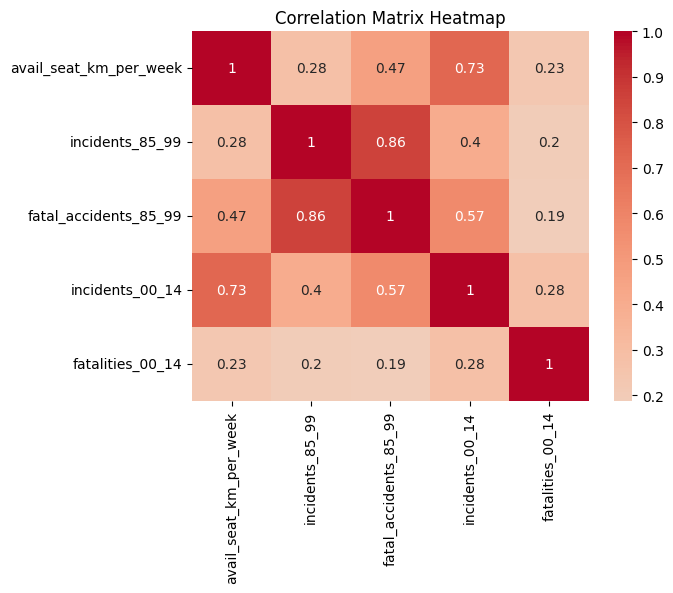

In [213]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

CUSTOM: Update these notes and use Markdown cells to narrate and tell the story as you explore. For example:

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **gpp** and **co2** show strong positive correlation (~0.98).

This is a Markdown cell.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

2026-06-09 13:45:28 | INFO | P06-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-09 13:45:28 | INFO | P06-NB | ----   Use clean dataframe ---------------------------
2026-06-09 13:45:28 | INFO | P06-NB | ----   Set x to Available seat km per week -----------------------
2026-06-09 13:45:28 | INFO | P06-NB | ----   Set y to Incidents (2000–2014) --------------------------
2026-06-09 13:45:28 | INFO | P06-NB | ----   Set the hue (color mapping) to the group column --


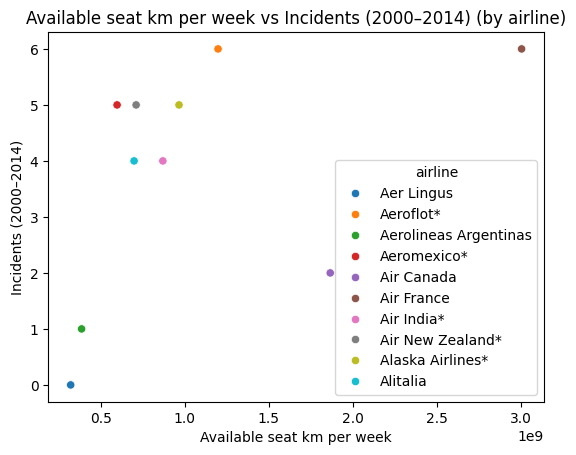

In [214]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info(f"----   Set x to {SCATTER_X_LABEL} -----------------------")
LOG.info(f"----   Set y to {SCATTER_Y_LABEL} --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_plot,
    x=SCATTER_X_COL,
    y=SCATTER_Y_COL,
    hue=GROUP_COL,
)

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel(SCATTER_X_LABEL)
scatter_plt.set_ylabel(SCATTER_Y_LABEL)

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title(f"{SCATTER_X_LABEL} vs {SCATTER_Y_LABEL} (by {GROUP_COL})")

# IN NOTEBOOK: SHOW AS YOU GO
#      plt.show() displays the current chart and closes it
#      Call this before starting a new chart
#      or next chart will be drawn on top of this one
# IN SCRIPT: WAIT TO SHOW TILL THE END
#      Do not call plt.show() here - let figures accumulate
#      so all charts display together with sequential Figure numbers.
#      plt.show() is called once at the end of make_plots()
plt.show()

2026-06-09 13:45:29 | INFO | P06-NB | ------- Creating another chart -------
2026-06-09 13:45:29 | INFO | P06-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-09 13:45:29 | INFO | P06-NB | ------   Use clean dataframe --------------------------
2026-06-09 13:45:29 | INFO | P06-NB | ------   Set x to the group column --------------------
2026-06-09 13:45:29 | INFO | P06-NB | ------   Set y to Fatalities (2000–2014) ----------------------


<Figure size 640x480 with 0 Axes>

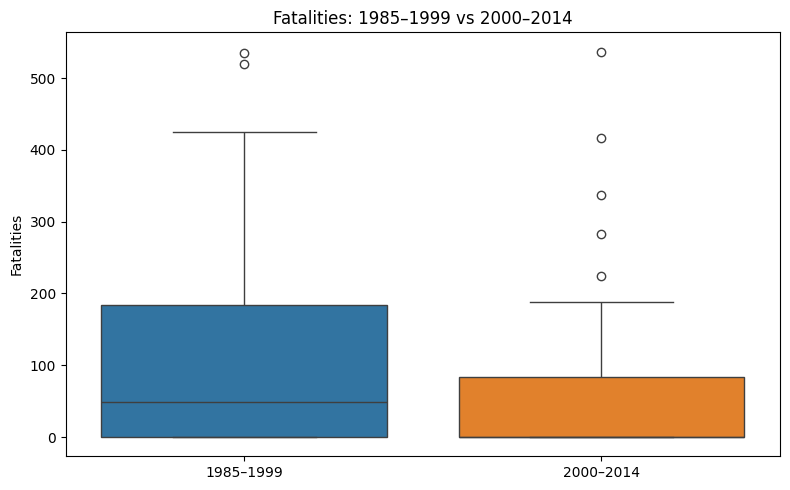

In [215]:
LOG.info("------- Creating another chart -------")
# plt.figure() opens a fresh blank canvas for the next chart
# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to the group column --------------------")
LOG.info(f"------   Set y to {BOX_Y_LABEL} ----------------------")

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean[["fatalities_85_99", "fatalities_00_14"]])

plt.title("Fatalities: 1985–1999 vs 2000–2014")
plt.ylabel("Fatalities")
plt.xticks([0, 1], ["1985–1999", "2000–2014"])

plt.tight_layout()
plt.show()

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [216]:
# Section 9 Python cell

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column (e.g. species names)
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them alphabetically so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("======================")
LOG.info("Review the results. ")
LOG.info("Determine the strongest correlations. ")
LOG.info("======================")
LOG.info("Look for interesting patterns in the charts. ")
LOG.info("Repeat the process, exploring additional angles.")
LOG.info("After finding interesting insights, conclude your analysis.")
LOG.info("======================")
LOG.info("Include instructions and specifics in your README.md file.")
LOG.info("Write up your narrative on your docs/index.md file.")
LOG.info("Include your next step suggestions for further analysis or modeling.")
LOG.info("======================")

LOG.info("EDA workflow complete")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-09 13:45:29 | INFO | P06-NB | ========================
2026-06-09 13:45:29 | INFO | P06-NB | SUMMARY
2026-06-09 13:45:29 | INFO | P06-NB | ========================
2026-06-09 13:45:29 | INFO | P06-NB | Dataset: airline-safety
2026-06-09 13:45:29 | INFO | P06-NB | Original rows: 56
2026-06-09 13:45:29 | INFO | P06-NB | Clean rows:    56
2026-06-09 13:45:29 | INFO | P06-NB | Groups found in airline: ['Aer Lingus', 'Aeroflot*', 'Aerolineas Argentinas', 'Aeromexico*', 'Air Canada', 'Air France', 'Air India*', 'Air New Zealand*', 'Alaska Airlines*', 'Alitalia', 'All Nippon Airways', 'American*', 'Austrian Airlines', 'Avianca', 'British Airways*', 'COPA', 'Cathay Pacific*', 'China Airlines', 'Condor', 'Delta / Northwest*', 'Egyptair', 'El Al', 'Ethiopian Airlines', 'Finnair', 'Garuda Indonesia', 'Gulf Air', 'Hawaiian Airlines', 'Iberia', 'Japan Airlines', 'KLM*', 'Kenya Airways', 'Korean Air', 'LAN Airlines', 'Lufthansa*', 'Malaysia Airlines', 'Pakistan International', 'Philippine Ai

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
